# Put swing 2027 — 10, 30, 90 and 180 days

One contract, four sizes. The same swing over calendar 2027, exercisable on 10, 30, 90 or
180 days out of the year, priced side by side.

**How to use:** edit **§1 Curve** and **§2 Deal**, then Run All. Everything below is output.

The interesting question is how the price per MWh moves with the number of days. A 10-day
swing takes only the very cheapest days, so it buys well below the average forward; a 180-day
swing has to take half the year and converges towards it. That gap is the optionality you are
paying for.

Conventions — signs, units, what `delta` means — are in
[docs/MODEL-CONVENTIONS.md](docs/MODEL-CONVENTIONS.md); the traps are at the bottom.

In [1]:
import time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import storage_model as sm

pd.set_option("display.width", 200, "display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (13, 3.4), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)
# A stale kernel is the classic way to get puzzling results here: `import
# storage_model` is cached, and run_valuation drops params it does not know
# without complaining -- so an old module would silently ignore DISCOUNT_RATE and
# every number would look unchanged. Fail here instead.
import inspect
if "discount_rate" not in inspect.signature(sm.Storage.__init__).parameters:
    raise RuntimeError(
        "The loaded storage_model has no `discount_rate` — this kernel is running an "
        "older copy of the library, and DISCOUNT_RATE below would be silently ignored. "
        "Restart the kernel (Kernel > Restart Kernel and Run All Cells).")
if "delta_pv" not in inspect.getsource(sm.Storage.build):
    raise RuntimeError(
        "The loaded storage_model does not produce `delta_pv` — stale kernel; restart it.")

print(f"ready — storage_model from {sm.__file__}")


ready — storage_model from H:\My Drive\Github\dmitry-goryunov\Storage\storage_model.py


## 1. Curve

Three sources, and **the choice of source decides whether `AS_OF` means anything**:

| `CURVE_SOURCE` | what it reads | `AS_OF` |
|---|---|---|
| `"quotes"` | `ttf q.xlsx` — the TTF quote matrix, one row per trading day | selects the row: the last quote on or before this date |
| `"csv"` | `curve.csv` — one stored curve, no quote date attached | **must be `None`**; there is no row to select |
| `"flat"` | nothing — a synthetic curve at `FLAT_LEVEL` for every month | the date the curve starts |

Setting `AS_OF` while the source is `"csv"` now raises instead of being quietly
ignored. The valuation date is not a third knob: it comes out of the curve, because
`VAL_DATE = None` means "value on the day this curve was quoted". Set it explicitly
only to value *after* the quote — never before, which would price a date off a curve
that did not exist yet, and which the library now rejects.

**`"flat"` is the sense-check setting.** A curve with no shape has no day-selection
value, so every number below collapses to something you can predict: `intrinsic` is
exactly 0 with no discount rate, `extrinsic` is exactly 0 with no vol, and a deal
forced to take every day in the window pays exactly `FLAT_LEVEL`. Use it to isolate
one effect at a time — and use it *instead of* editing a row of `ttf q.xlsx` flat,
which changes every other valuation reading that file and cannot be undone from the
spreadsheet.

flat 40 EUR/MWh: 49 contracts, 01 Mar 26 .. Mar 30, 40.00-40.00 EUR/MWh   |   valued 2026-03-06


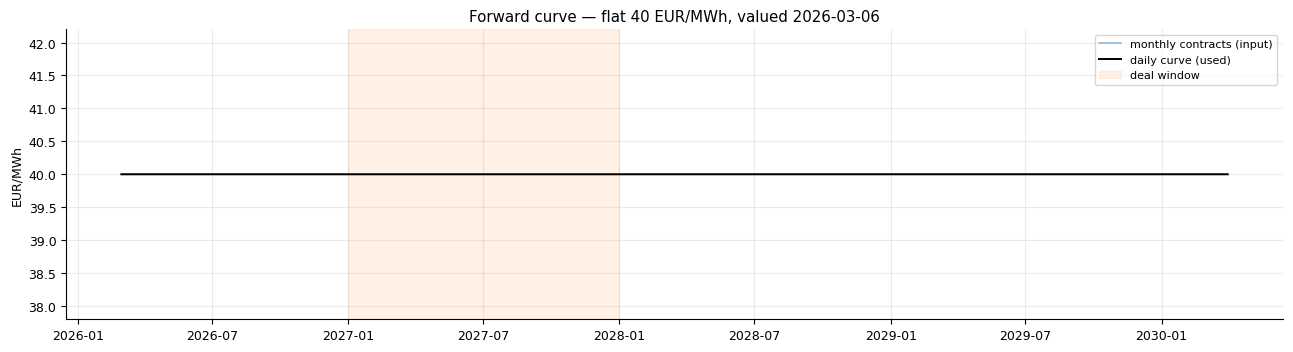

m,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
y,,,,,,,,,,,,
2026,,,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00
2027,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00
2028,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00
2029,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00,40.00
2030,40.00,40.00,40.00,,,,,,,,,


In [2]:
CURVE_SOURCE = "flat"      # "quotes" -> ttf q.xlsx | "csv" -> curve.csv | "flat" -> synthetic
AS_OF        = pd.Timestamp("2026-03-06")   # quote row to price off; "quotes" and "flat"
FLAT_LEVEL   = 40.0                         # "flat" only: one price for every month
VAL_DATE     = None                         # None -> value on the curve's own start date


def load_curve(source=CURVE_SOURCE, as_of=AS_OF, flat_level=FLAT_LEVEL):
    """Return (curve, label, curve_start).

    The start date comes *out* of here rather than in: a curve and the date it is
    valued on are one choice, and letting them be set separately is how you end up
    valuing January off a March quote.
    """
    if source == "flat":
        # A deliberately shapeless curve, for sense checks. Every reported number
        # then has an answer you can state in advance: intrinsic is exactly 0
        # without a rate, extrinsic is exactly 0 without vol, and a deal forced to
        # take every day pays exactly flat_level. It needs no data file, which is
        # the point -- do not flatten a row of `ttf q.xlsx` to get here, because
        # that quietly changes every other valuation that reads the same file.
        if as_of is None:
            raise ValueError("CURVE_SOURCE = 'flat' needs an AS_OF date to start the curve.")
        start = sm.month_start(pd.Timestamp(as_of))
        starts = pd.date_range(start, start + pd.DateOffset(years=4), freq="MS")
        c = pd.DataFrame({"contractStart": starts,
                          "contractEnd": starts.map(sm.month_end),
                          "value": float(flat_level)})
        return c, f"flat {flat_level:g} EUR/MWh", pd.Timestamp(as_of)

    if source == "csv":
        if as_of is not None:
            raise ValueError(
                "AS_OF selects a quote row out of 'ttf q.xlsx'. curve.csv is a single "
                "stored curve with no quote date attached, so AS_OF would do nothing "
                "here. Set CURVE_SOURCE = 'quotes' to price off a date, or AS_OF = None.")
        c = pd.read_csv("curve.csv")
        c["contractStart"] = pd.to_datetime(c["contractStart"], format="mixed")
        c["contractEnd"]   = pd.to_datetime(c["contractEnd"],   format="mixed")
        c = c.sort_values("contractStart").reset_index(drop=True)
        return c, "curve.csv", c["contractStart"].min()

    if source != "quotes":
        raise ValueError(f"CURVE_SOURCE must be 'quotes', 'csv' or 'flat', not {source!r}")
    if as_of is None:
        raise ValueError("CURVE_SOURCE = 'quotes' needs an AS_OF quote date.")

    import re
    q = pd.read_excel("ttf q.xlsx")
    q = q.rename(columns={q.columns[0]: "quote_date"}).dropna(subset=["quote_date"])
    q["quote_date"] = pd.to_datetime(q["quote_date"], format="mixed")
    q = q.sort_values("quote_date").reset_index(drop=True)
    cols = sorted([c for c in q.columns if re.fullmatch(r"TTFc\d+", str(c))],
                  key=lambda c: int(re.search(r"\d+", str(c)).group()))
    row = sm.quote_row_for_fd_date(q, cols, as_of)
    quote_date = pd.Timestamp(row["quote_date"])
    if quote_date != pd.Timestamp(as_of):
        print(f"note: no quote on {pd.Timestamp(as_of):%Y-%m-%d}; using the last one "
              f"before it, {quote_date:%Y-%m-%d}")
    return (sm.curve_df_for_storage(row, cols, curve_start=quote_date, include_da=True),
            f"ttf q.xlsx @ {quote_date:%Y-%m-%d}", quote_date)


CURVE, CURVE_LABEL, CURVE_START = load_curve()
VAL_DATE = CURVE_START if VAL_DATE is None else pd.Timestamp(VAL_DATE)
print(f"{CURVE_LABEL}: {len(CURVE)} contracts, {CURVE['contractStart'].min():%d %b %y} .. "
      f"{CURVE['contractEnd'].max():%b %y}, "
      f"{CURVE['value'].min():.2f}-{CURVE['value'].max():.2f} EUR/MWh"
      f"   |   valued {VAL_DATE:%Y-%m-%d}")

# The curve everything below is priced off. Two things are worth seeing: the
# monthly contracts as given, and the daily curve the model actually uses, which
# is smoothed through the monthly midpoints and then corrected so each month's
# daily average reproduces its contract exactly.
_span  = pd.date_range(CURVE["contractStart"].min(), CURVE["contractEnd"].max(), freq="D")
_daily = sm.smoothen_curve(sm.map_curve_to_dates(_span, CURVE))

fig, ax = plt.subplots(figsize=(13, 3.6))
ax.step(list(CURVE["contractStart"]) + [CURVE["contractEnd"].max()],
        list(CURVE["value"]) + [CURVE["value"].iloc[-1]],
        where="post", color="tab:blue", alpha=.45, lw=1.3, label="monthly contracts (input)")
ax.plot(_daily.index, _daily.values, color="black", lw=1.4, label="daily curve (used)")
ax.axvspan(pd.Timestamp("2027-01-01"), pd.Timestamp("2027-12-31"),
           color="tab:orange", alpha=.10, label="deal window")
ax.set_ylabel("EUR/MWh")
ax.set_title(f"Forward curve — {CURVE_LABEL}, valued {VAL_DATE:%Y-%m-%d}")
ax.legend(loc="best", fontsize=8)
plt.tight_layout(); plt.show()

_m = CURVE.assign(y=CURVE["contractStart"].dt.year, m=CURVE["contractStart"].dt.strftime("%b"))
_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
display(_m.pivot(index="y", columns="m", values="value")
        .reindex(columns=_order).dropna(axis=1, how="all")
        .style.format("{:.2f}", na_rep="")
        .set_caption("Monthly contracts, EUR/MWh — the input the daily curve is built from"))

## 2. Deal

`DAY_COUNTS` is the list of sizes to compare. Capacity follows from it:
`days x MWH_PER_DAY`.

`PRODUCT_TYPE` is `put_swing` — in this model that is the obligation to **buy** on the
cheapest days. Switch it to `call_swing` for the sell side (the right to sell on the dearest
days); everything below adapts, including the signs.

`DISCOUNT_RATE` is where time value goes: the annual rate at which cash released by the
deal can be redeployed, continuously compounded. It makes a euro on day *i* worth
`exp(-r·i/365.25)` today, so the optimiser stops treating every day as equally good.
**The two sides move in opposite directions** — a seller pulls exercise earlier to get the
cash, a buyer pushes it later to keep it. Leave it at `0.0` to switch time value off.

`STRIKE` is the fixed leg, in EUR/MWh. At `0.0` the deal simply pays (or receives) the
index. Set it and a put swing pays `price - STRIKE` per MWh, a call swing receives
`STRIKE - price`; the `price` column below is that net figure, not the raw index. The
`flat` benchmark is net of it too — a constant per-MWh amount cannot reorder the exercise
days, so benchmarking a strike-net value against a raw forward average would shift
`intrinsic` by the strike while the day-selection spread it measures did not move.

put_swing (buy-side), 2027-01-01 .. 2027-12-31 = 365 days, strike 0.00 EUR/MWh, discounted at 10%
     10 days =   10,000 MWh   ( 2.7% of the window)
     30 days =   30,000 MWh   ( 8.2% of the window)
     90 days =   90,000 MWh   (24.7% of the window)
    180 days =  180,000 MWh   (49.3% of the window)


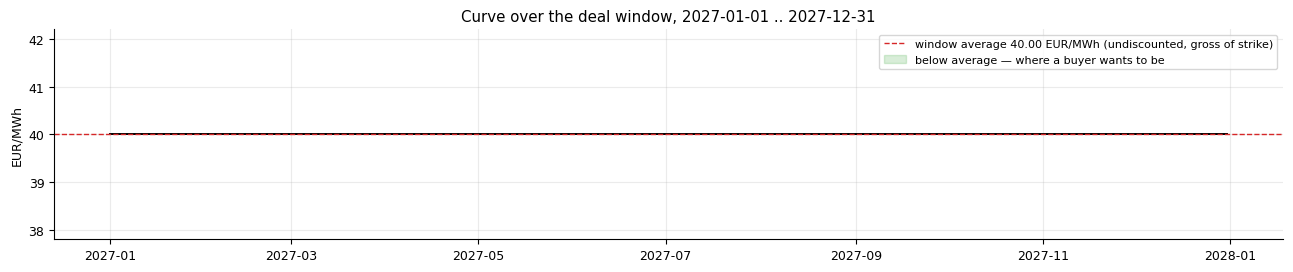

window: min 40.00  mean 40.00  max 40.00 EUR/MWh  (spread 0.00)
the mean above is gross of strike and undiscounted; the `flat` benchmark in the tables below is net of the 0.00 strike and present-valued, at 35.060 EUR/MWh.


In [3]:
PRODUCT_TYPE  = "put_swing"                 # "put_swing" = buy | "call_swing" = sell
START, END    = "2027-01-01", "2027-12-31"
DAY_COUNTS    = [10, 30, 90, 180]
MWH_PER_DAY   = 1_000
STRIKE        = 0.0     # EUR/MWh against the index; 0.0 = pay/receive the index itself

VOL           = 0.50    # annualised
SMR           = 1.0     # mean reversion per year
DISCOUNT_RATE = 0.10    # annual, continuously compounded; 0.0 = no time value
N_P           = 30      # price-tree half-width; checked in section 6
CLIPS_PER_DAY = 1       # exercise is all-or-nothing on a day

WINDOW_DAYS = (pd.Timestamp(END) - pd.Timestamp(START)).days + 1
SIDE = "buy" if PRODUCT_TYPE == "put_swing" else "sell"
print(f"{PRODUCT_TYPE} ({SIDE}-side), {START} .. {END} = {WINDOW_DAYS} days, "
      f"strike {STRIKE:.2f} EUR/MWh, discounted at {DISCOUNT_RATE:.0%}")
for d in DAY_COUNTS:
    print(f"   {d:4d} days = {d * MWH_PER_DAY:>8,} MWh   ({d / WINDOW_DAYS:5.1%} of the window)")

# The slice of that curve the deal actually exercises over.
_win = pd.date_range(START, END, freq="D")
_dc = sm.smoothen_curve(sm.map_curve_to_dates(
    pd.date_range(CURVE["contractStart"].min(), CURVE["contractEnd"].max(), freq="D"), CURVE))
_dw = _dc.reindex(_win)
fig, ax = plt.subplots(figsize=(13, 2.8))
ax.plot(_dw.index, _dw.values, color="black", lw=1.4)
ax.axhline(_dw.mean(), color="tab:red", ls="--", lw=1,
           label=f"window average {_dw.mean():.2f} EUR/MWh (undiscounted, gross of strike)")
ax.fill_between(_dw.index, _dw.values, _dw.mean(), where=_dw.values < _dw.mean(),
                color="tab:green", alpha=.18, label="below average — where a buyer wants to be")
ax.set_ylabel("EUR/MWh"); ax.legend(loc="best", fontsize=8)
ax.set_title(f"Curve over the deal window, {START} .. {END}")
plt.tight_layout(); plt.show()
_pv = float(((_dw.values - STRIKE) * np.exp(-DISCOUNT_RATE *
             np.arange((pd.Timestamp(START) - VAL_DATE).days,
                       (pd.Timestamp(START) - VAL_DATE).days + len(_dw)) / 365.25)).mean())
print(f"window: min {_dw.min():.2f}  mean {_dw.mean():.2f}  max {_dw.max():.2f} EUR/MWh  "
      f"(spread {_dw.max() - _dw.min():.2f})")
print(f"the mean above is gross of strike and undiscounted; the `flat` benchmark in the tables "
      f"below is net of the {STRIKE:.2f} strike and present-valued, at {_pv:.3f} EUR/MWh.")


## 3. Run

Every deal is checked as it is priced:

- **volume** — gross MWh moved, against the capacity asked for
- **invariant** — the reported hedge must reprice the contract,

  `V0 = sum_i DF_i*delta_i*fwd_i - sum_i DF_i*(inj_cost_i*injected_i + wdr_cost_i*withdrawn_i)`

  The cost term matters whenever there is a strike or an injection cost: those are fixed cash
  amounts that do not scale with the price level. Without them the simpler
  `sum(DF*delta*fwd) == V0` only holds for a zero-cost deal.

In [4]:
def price(days, n_p=None, run_intrinsic=True, discount_rate=None):
    params = dict(product_type=PRODUCT_TYPE, valDate=VAL_DATE,
                  storageStart=START, storageEnd=END,
                  capacity_mwh=days * MWH_PER_DAY, daily_max=MWH_PER_DAY,
                  clips_per_day=CLIPS_PER_DAY, vol=VOL, sMR=SMR, strike=STRIKE,
                  discount_rate=DISCOUNT_RATE if discount_rate is None else discount_rate,
                  n_p_full=N_P if n_p is None else n_p, run_intrinsic=run_intrinsic)
    t0 = time.perf_counter()
    s, r = sm.run_valuation(CURVE, params)
    secs = time.perf_counter() - t0

    n  = s.n_t
    dl = np.asarray(s.delta[:n]); df = s.d_curve[:n]
    v0 = float(s.v[0, s.n_p, s.initial_state])
    moved = s.prob[:n] * s.strat[:n] * s.v_step
    injected  = np.clip(moved, 0, None).sum(axis=(1, 2))
    withdrawn = -np.clip(moved, None, 0).sum(axis=(1, 2))
    cash = np.dot(df, np.asarray(s.i_cost)[:n] * injected
                      + np.asarray(s.w_cost)[:n] * withdrawn)
    gross = float(injected.sum() + withdrawn.sum())

    diag = dict(v0=v0, gross_mwh=gross, delta_mwh=float(dl.sum()),
                price_per_mwh=abs(v0) / gross if gross else np.nan,
                invariant=abs(float(np.dot(df * dl, s.fwd) - cash) - v0) / max(abs(v0), 1.0),
                starts=s.initial_state, n_states=s.n_states, secs=secs)

    # Split the intrinsic leg. Choosing days is worth two different things once a
    # rate is on: what the schedule saves on price, and what it saves purely by
    # settling later. A flat forward curve is not flat after discounting, so the
    # second is live even with no price shape -- and on a flat curve it is the
    # whole of intrinsic. Needs the deterministic run, which is nearly free.
    if run_intrinsic:
        det, _ = sm.run_valuation(CURVE, {**params, "n_p_full": 0, "run_intrinsic": False})
        # The strike has to reach the split too: both legs it divides out are
        # net of it, so passing the run's strike is not optional.
        diag["shape"], diag["financing"] = sm.intrinsic_components(det, strike=STRIKE)
    else:
        diag["shape"] = diag["financing"] = np.nan
    return s, r, diag


RUNS = {}
for d in DAY_COUNTS:
    s, r, g = price(d)
    RUNS[d] = (s, r, g)
    print(f"  {d:4d} days   {g['secs']:5.1f}s   {g['gross_mwh']:>9,.0f} MWh "
          f"{SIDE}   {g['price_per_mwh']:7.3f} EUR/MWh   invariant {g['invariant']:.0e}")

    10 days     0.6s      10,000 MWh buy    31.164 EUR/MWh   invariant 4e-16


    30 days     0.2s      30,000 MWh buy    31.378 EUR/MWh   invariant 7e-16


    90 days     0.2s      90,000 MWh buy    32.017 EUR/MWh   invariant 3e-16


   180 days     0.3s     180,000 MWh buy    32.986 EUR/MWh   invariant 5e-16


## 4. Price against size

`price` is the average price actually paid (or received) per MWh, **net of `STRIKE`**. `flat` is the unweighted
average forward over the window — what you would get with no choice of days. The gap between
them is what the swing is worth.

`intrinsic` splits into **`shape`** and **`financing`**, which sum to it exactly. `shape` is
what the schedule saves on price by picking better days. `financing` is what it saves by
settling on later ones, which is worth something only because `DISCOUNT_RATE` is not zero.
**On a flat curve `shape` is exactly zero and `financing` is the whole of intrinsic** — a
flat forward curve is not flat once discounted, so there is still something to choose. That
is a hurdle-rate gain on deferred cash, not a commodity gain: you realise it by actually
deferring, not by trading anything.

,MWh,% of window,strike,buy price EUR/MWh,flat EUR/MWh,vs flat,intrinsic,shape,financing,extrinsic,total,value EUR,delta MWh,invariant
days,,,,,,,,,,,,,,
10,"10,000",2.7%,0.00,31.164,35.060,+3.895,1.677,-0.000,1.677,2.218,3.895,"-311,645","-9,021",4e-16
30,"30,000",8.2%,0.00,31.378,35.060,+3.682,1.585,-0.000,1.585,2.097,3.682,"-941,330","-27,224",7e-16
90,"90,000",24.7%,0.00,32.017,35.060,+3.043,1.309,-0.000,1.309,1.734,3.043,"-2,881,530","-83,127",3e-16
180,"180,000",49.3%,0.00,32.986,35.060,+2.074,0.888,-0.000,0.888,1.187,2.074,"-5,937,452","-170,657",5e-16


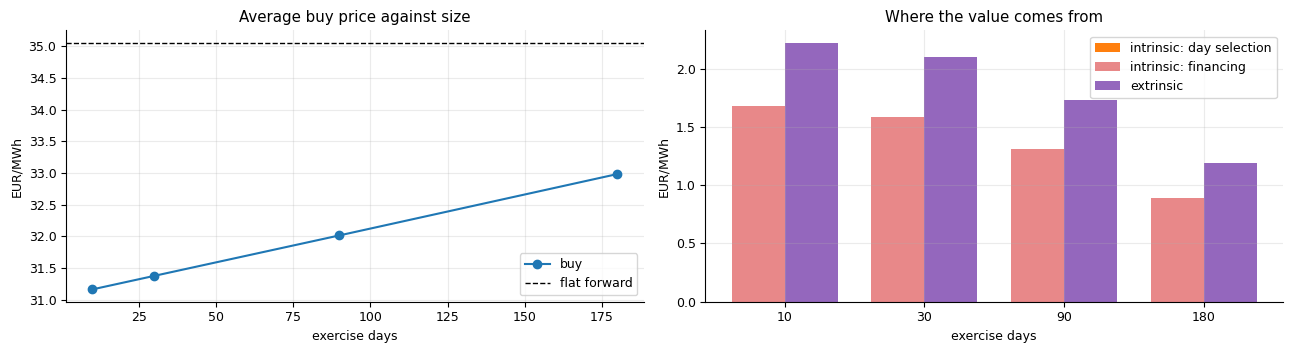

invariant worst case 7.4e-16
inventory: starts at 0 clips of 10 — a put swing starts empty and must fill; a call swing starts full and must empty.


In [5]:
rows = []
for d, (s, r, g) in RUNS.items():
    flat = r["flat_metric"]
    rows.append({
        "days": d,
        "MWh": g["gross_mwh"],
        "% of window": d / WINDOW_DAYS,
        "strike": STRIKE,
        f"{SIDE} price EUR/MWh": g["price_per_mwh"],
        "flat EUR/MWh": flat,
        "vs flat": (flat - g["price_per_mwh"]) if SIDE == "buy" else (g["price_per_mwh"] - flat),
        "intrinsic": r["intrinsic"],
        "shape": g["shape"],
        "financing": g["financing"],
        "extrinsic": r["extrinsic"],
        "total": r["total"],
        "value EUR": g["v0"],
        "delta MWh": g["delta_mwh"],
        "invariant": g["invariant"],
    })
summary = pd.DataFrame(rows).set_index("days")
display(summary.style.format({
        "MWh": "{:,.0f}", "% of window": "{:.1%}", "strike": "{:.2f}",
        f"{SIDE} price EUR/MWh": "{:.3f}",
        "flat EUR/MWh": "{:.3f}", "vs flat": "{:+.3f}", "intrinsic": "{:.3f}",
        "shape": "{:.3f}", "financing": "{:.3f}",
        "extrinsic": "{:.3f}", "total": "{:.3f}", "value EUR": "{:,.0f}",
        "delta MWh": "{:,.0f}", "invariant": "{:.0e}"})
    .set_caption(f"{PRODUCT_TYPE} {START}..{END}, {MWH_PER_DAY:,} MWh/day, strike {STRIKE:.2f}, "
                 f"vol {VOL:.0%}, n_p {N_P} — valued {VAL_DATE:%Y-%m-%d} off {CURVE_LABEL}"))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(summary.index, summary[f"{SIDE} price EUR/MWh"], "o-", color="tab:blue", label=SIDE)
ax[0].axhline(summary["flat EUR/MWh"].iloc[0], color="black", ls="--", lw=1, label="flat forward")
ax[0].set_xlabel("exercise days"); ax[0].set_ylabel("EUR/MWh")
ax[0].set_title(f"Average {SIDE} price against size"); ax[0].legend()

w, _x = 0.38, np.arange(len(summary))
ax[1].bar(_x - w/2, summary["shape"], w, label="intrinsic: day selection", color="tab:orange")
ax[1].bar(_x - w/2, summary["financing"], w, bottom=summary["shape"],
          label="intrinsic: financing", color="tab:red", alpha=.55)
ax[1].bar(_x + w/2, summary["extrinsic"], w, label="extrinsic", color="tab:purple")
ax[1].set_xticks(_x); ax[1].set_xticklabels(summary.index)
ax[1].set_xlabel("exercise days"); ax[1].set_ylabel("EUR/MWh")
ax[1].set_title("Where the value comes from"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"invariant worst case {summary['invariant'].max():.1e}")
print(f"inventory: starts at {RUNS[DAY_COUNTS[0]][2]['starts']} clips of "
      f"{RUNS[DAY_COUNTS[0]][2]['n_states']} — a put swing starts empty and must fill; a call "
      f"swing starts full and must empty.")

## 5. When does each size exercise?

Expected MWh per day. The small deal waits for the cheapest days and does nothing else; the
large one has to take most of the year and starts running out of choice.

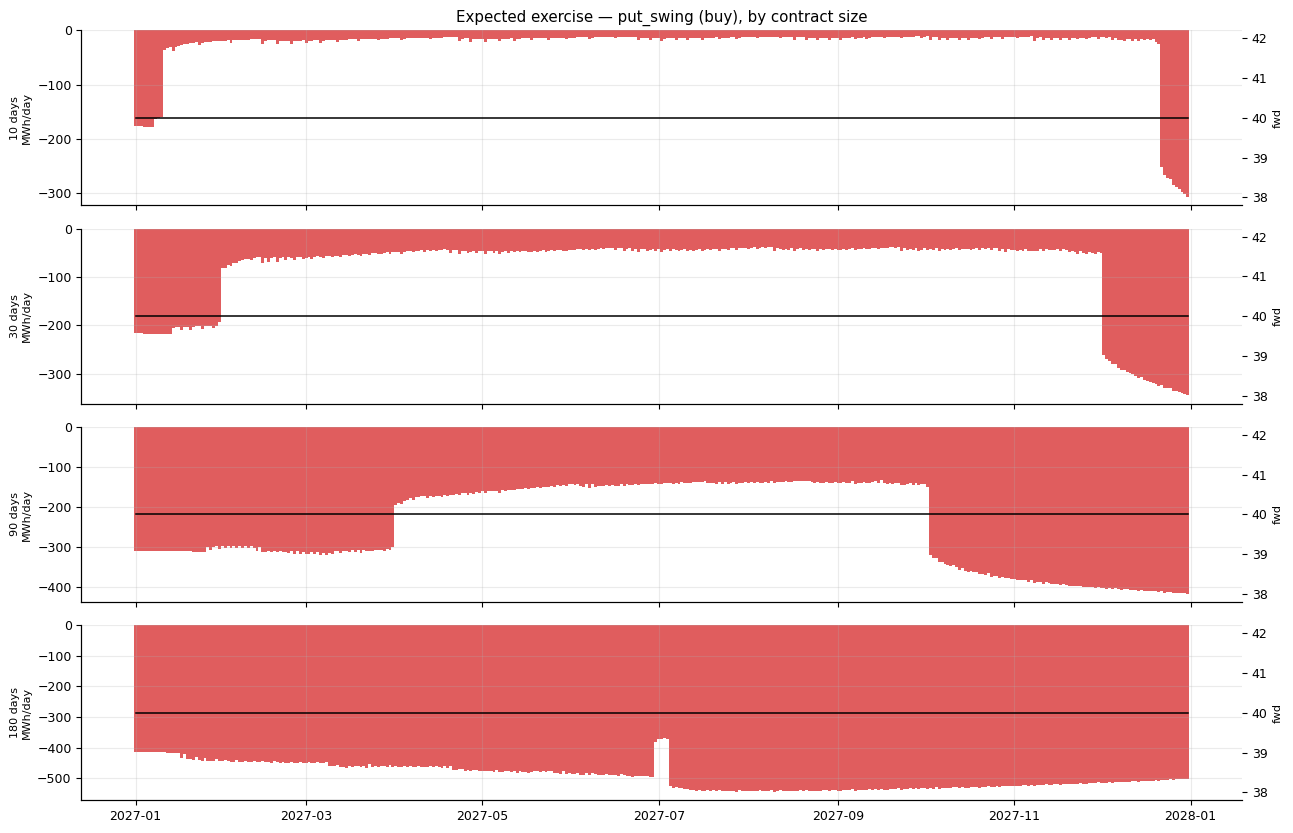

In [6]:
fig, axes = plt.subplots(len(RUNS), 1, figsize=(13, 2.1 * len(RUNS)), sharex=True)
for ax, (d, (s, r, g)) in zip(np.atleast_1d(axes), RUNS.items()):
    idx = pd.DatetimeIndex(s.date_span[:s.n_t])
    win = slice(s.Dt, s._active)
    ex = pd.Series(np.asarray(s.exp_ex[:s.n_t]), index=idx).iloc[win]
    px = pd.Series(s.fwd, index=idx).iloc[win]
    ax.bar(ex.index, ex.values, width=1.0,
           color="tab:red" if SIDE == "buy" else "tab:green", alpha=.75)
    ax.set_ylabel(f"{d} days\nMWh/day", fontsize=8)
    twin = ax.twinx(); twin.plot(px.index, px.values, color="black", lw=1.1)
    twin.set_ylabel("fwd", fontsize=8); twin.grid(False)
axes[0].set_title(f"Expected exercise — {PRODUCT_TYPE} ({SIDE}), by contract size")
plt.tight_layout(); plt.show()

## 6b. What the discount rate does

The deal repriced across rates, holding everything else fixed. `mean day` is the
volume-weighted exercise day within the window, so it shows the schedule moving, not just
the value. A buyer defers to keep the cash; a seller accelerates to get it.


In [7]:
rows = []
for rate in (0.0, 0.05, DISCOUNT_RATE, 0.20):
    s, r, g = price(30, discount_rate=rate)
    ex = np.abs(np.asarray(s.exp_ex[:s.n_t]))
    rows.append({"rate": rate,
                 f"{SIDE} price EUR/MWh": g["price_per_mwh"],
                 "flat EUR/MWh": r["flat_metric"],
                 "intrinsic": r["intrinsic"], "extrinsic": r["extrinsic"],
                 "value EUR": g["v0"],
                 "mean day": float(np.dot(np.arange(s.n_t), ex) / ex.sum()) - s.Dt})
rates = pd.DataFrame(rows).set_index("rate")
display(rates.style.format({f"{SIDE} price EUR/MWh": "{:.3f}", "flat EUR/MWh": "{:.3f}",
                            "intrinsic": "{:.3f}", "extrinsic": "{:.3f}",
                            "value EUR": "{:,.0f}", "mean day": "{:.0f}"})
        .format_index("{:.0%}")
        .set_caption(f"30-day deal repriced by discount rate — day 0 is {START}"))
print("`flat` is PV'd at the same rate, so `intrinsic` stays a like-for-like comparison:")
print("it measures choosing days, not the discounting itself.")


,buy price EUR/MWh,flat EUR/MWh,intrinsic,extrinsic,value EUR,mean day
rate,,,,,,
0%,36.049,40.000,0.000,3.951,"-1,081,482",146
5%,33.686,37.445,0.853,2.906,"-1,010,585",171
10%,31.378,35.060,1.585,2.097,"-941,330",194
20%,26.986,30.755,2.742,1.028,"-809,569",241


`flat` is PV'd at the same rate, so `intrinsic` stays a like-for-like comparison:
it measures choosing days, not the discounting itself.


## 6. Monthly schedule and hedge

Three different questions, three different numbers. Reading the wrong one is the easiest
mistake this model invites.

| | what it answers | when it is the right column |
|---|---|---|
| **physical** | how much gas do I expect to actually move | procurement, capacity booking, volume planning |
| **forward hedge** | how many MWh of forward immunise the mark | hedging price risk with an OTC forward settling with the deal |
| **futures hedge** | the same, tailed by the discount factor | hedging with margined futures, and PV risk reporting |

They diverge because `delta / physical = E[S | exercise] / F`. In the back months a
mandatory swing is *forced* to exercise on the paths where prices stayed high, so the
price-risk exposure exceeds the volume; in the cheap months, where exercise is chosen, it
falls short. Hedging the back month at its delta over-buys the gas you will physically
need — and hedging it at the physical volume under-hedges the price risk. Both are correct;
pick by the question.

These remain **local** ratios: correct derivatives, but strongly convex, so re-hedge rather
than holding them across a large move.

In [8]:
# Cross-size comparison, on the PHYSICAL requirement.
physical = {}
for d, (s, r, g) in RUNS.items():
    idx = pd.DatetimeIndex(s.date_span[:s.n_t])
    physical[f"{d} days"] = pd.Series(np.asarray(s.exp_ex[:s.n_t]), index=idx
                                      ).iloc[s.Dt:s._active].resample("MS").sum()
physical = pd.DataFrame(physical).round(0)
physical.index = physical.index.strftime("%b-%y")
physical.loc["TOTAL"] = physical.sum()
display(physical.style.format("{:,.0f}")
        .set_caption("Expected PHYSICAL volume by month, MWh (negative = buy)"))

# One size broken out three ways, so the divergence is explicit.
BREAKOUT = 10          # which contract size to break out

s, r, g = RUNS[BREAKOUT]
idx = pd.DatetimeIndex(s.date_span[:s.n_t]); win = slice(s.Dt, s._active)
cols = {
    "physical": pd.Series(np.asarray(s.exp_ex[:s.n_t]), index=idx).iloc[win],
    "forward hedge": pd.Series(np.asarray(s.delta[:s.n_t]), index=idx).iloc[win],
    "futures hedge": pd.Series(np.asarray(s.delta_pv[:s.n_t]), index=idx).iloc[win],
}
brk = pd.DataFrame({k: v.resample("MS").sum() for k, v in cols.items()})
brk["hedge / physical"] = brk["forward hedge"] / brk["physical"]
brk.index = brk.index.strftime("%b-%y")
brk.loc["TOTAL"] = brk.sum()
brk.loc["TOTAL", "hedge / physical"] = (brk.loc["TOTAL", "forward hedge"]
                                        / brk.loc["TOTAL", "physical"])
display(brk.style.format({"physical": "{:,.0f}", "forward hedge": "{:,.0f}",
                          "futures hedge": "{:,.0f}", "hedge / physical": "{:.2f}"})
        .set_caption(f"{BREAKOUT}-day deal: the same month, three questions"))
print("A ratio above 1 means the price exposure exceeds the gas: exercise there is forced")
print("onto high-price paths. Below 1 means exercise is chosen, on cheap days.")

,10 days,30 days,90 days,180 days
Jan-27,"-2,262","-6,362","-9,562","-13,229"
Feb-27,-538,"-1,815","-8,589","-12,501"
Mar-27,-540,"-1,706","-9,645","-14,199"
Apr-27,-443,"-1,407","-5,219","-13,972"
May-27,-484,"-1,459","-4,764","-14,843"
Jun-27,-403,"-1,285","-4,358","-14,580"
Jul-27,-450,"-1,346","-4,324","-16,006"
Aug-27,-418,"-1,299","-4,262","-16,761"
Sep-27,-395,"-1,250","-4,207","-16,096"
Oct-27,-437,"-1,321","-10,650","-16,422"


,physical,forward hedge,futures hedge,hedge / physical
Jan-27,"-2,262","-1,394","-1,281",0.62
Feb-27,-538,-367,-334,0.68
Mar-27,-540,-378,-341,0.70
Apr-27,-443,-313,-280,0.71
May-27,-484,-352,-312,0.73
Jun-27,-403,-298,-262,0.74
Jul-27,-450,-342,-298,0.76
Aug-27,-418,-325,-281,0.78
Sep-27,-395,-315,-271,0.80
Oct-27,-437,-361,-308,0.83


A ratio above 1 means the price exposure exceeds the gas: exercise there is forced
onto high-price paths. Below 1 means exercise is chosen, on cheap days.


## 7. Is the tree wide enough?

`n_p` is the price-tree half-width. Too narrow and optionality is silently lost. The 10-day
deal is the most option-like, so it is the most demanding; if it is flat by the `N_P` you
chose, the rest are too.

In [9]:
conv = []
for n_p in (5, 10, 15, 20, 30, 45):
    s, r, g = price(min(DAY_COUNTS), n_p=n_p, run_intrinsic=False)
    conv.append({"n_p": n_p, "EUR/MWh": g["price_per_mwh"], "secs": g["secs"]})
conv = pd.DataFrame(conv).set_index("n_p")
conv["vs n_p=45"] = conv["EUR/MWh"] - conv.loc[45, "EUR/MWh"]
display(conv.style.format({"EUR/MWh": "{:.4f}", "vs n_p=45": "{:+.4f}", "secs": "{:.1f}"})
        .set_caption(f"Tree-width convergence — {min(DAY_COUNTS)}-day deal"))

,EUR/MWh,secs,vs n_p=45
n_p,,,
5,32.3537,0.2,+1.1892
10,31.2962,0.2,+0.1317
15,31.1669,0.2,+0.0024
20,31.1622,0.2,-0.0023
30,31.1645,0.2,-0.0001
45,31.1645,0.2,+0.0000


## Traps worth knowing

- **A curve has a date, and it is not a free parameter.** `AS_OF` picks the quote row;
  the valuation date follows it. The two used to be set separately, so leaving
  `VAL_DATE` behind an `AS_OF` you had moved forward stamped the quote's day-ahead
  price flat across the months in between. Both that and a silently-ignored `AS_OF`
  on the `csv` source now raise.
- **`delta` is not volume.** It is the forward MWh to trade — volume weighted by
  `E[S|exercise]/F` — so it exceeds volume when exercise happens at high prices and falls
  short when it happens at low ones. For a per-MWh price divide value by exercised volume,
  never by `delta`.
- **A put swing must buy.** It is an obligation, not a right: the quota is met on every path,
  which is why the small sizes look so good and the large ones do not. The right-not-obligation
  version is `call_swing` with `zero_penalty=True`.
- **The repricing identity carries a cost term** whenever there is a strike or an injection
  cost — see section 3.
- **The intrinsic split used to break with a strike** — `intrinsic = profiled - flat`
  compared a strike-net value with a raw forward average, so it moved by `K`: down for a
  call, up for a put. Fixed 2026-09-08; `flat_metric` is now reported net of the strike.
- **`exp_ex` is net per day**, which only matters for two-sided deals (storage).
- **The curve must reach one month past the deal** — the model carries a terminal condition
  past the last exercise day.
- **`sVol` and `sMR` are annualised** and their defaults are not calibrated to anything; see
  the calibration note in `docs/MODEL-CONVENTIONS.md`.